# NB 03 — Operator Interpolation

2D interpolants over the $(k, S)$ parameter grid so that $\hat{A}^*$, $\hat{B}^*$, $\hat{C}^*$ can be evaluated at any new $(k^*, S^*)$.

Interpolation is performed over $(\log_{10} k,\; S)$ space using `RBFInterpolator` with a thin-plate-spline kernel.  
`smoothing=0.5` avoids exact interpolation through potentially noisy operators at corner grid points.

## 0. Imports and paths

In [31]:
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import RBFInterpolator

plt.rcParams.update({
    'font.family':'DejaVu Serif','mathtext.fontset':'dejavuserif',
    'font.size':11,'axes.labelsize':12,'axes.titlesize':12,
    'axes.titleweight':'bold','legend.fontsize':10,
    'axes.grid':False,'axes.spines.top':True,'axes.spines.right':True,
    'lines.linewidth':2.0,'figure.dpi':130,'savefig.dpi':300,
})
C1,C2,C3,C4 = '#1a5e9e','#0d6e56','#9b2a1a','#b07318'

BASIS_DIR  = Path('../rom/basis')
OPS_DIR    = Path('../rom/operators')
INTERP_DIR = Path('../rom/interpolants')
INTERP_DIR.mkdir(parents=True, exist_ok=True)

K_GRID       = [10, 20, 50, 100, 200, 300]
S_GRID       = [0, 1, 2, 4, 6, 8]

Vn = np.load(BASIS_DIR / 'Vn.npy')
n  = Vn.shape[1]
print(f'n modes    : {n}')
print(f'Interp dir : {INTERP_DIR.resolve()}')

n modes    : 10
Interp dir : F:\Niloy Deb\Part Two\reservoir_rom\rom\interpolants


## 1. Load all inferred operators (stable points only)

In [32]:
log10k_pts, S_pts = [], []
A_list, B_list, C_list = [], [], []
excluded = []

for k in K_GRID:
    for s in S_GRID:
        tag    = f'k{k:03d}_s{s:02d}'
        op_dir = OPS_DIR / tag

        if not (op_dir / 'A_hat.npy').exists():
            excluded.append((tag, 'missing'))
            continue

        with open(op_dir / 'inference_report.json') as f:
            rep = json.load(f)

        if not rep['stable']:
            excluded.append((tag, f'unstable max_eig={rep["max_real_eig"]:.3f}'))
            continue

        log10k_pts.append(np.log10(k))
        S_pts.append(s)
        A_list.append(np.load(op_dir / 'A_hat.npy'))
        B_list.append(np.load(op_dir / 'B_hat.npy'))
        C_list.append(np.load(op_dir / 'C_hat.npy'))

pts   = np.column_stack([log10k_pts, S_pts])
A_arr = np.array(A_list)
B_arr = np.array(B_list)
C_arr = np.array(C_list)
M     = len(log10k_pts)

print(f'Training points used : {M} / 49')
if excluded:
    print(f'Excluded             : {len(excluded)}')
    for tag, reason in excluded:
        print(f'  {tag}  ({reason})')

Training points used : 26 / 49
Excluded             : 10
  k010_s06  (missing)
  k010_s08  (missing)
  k020_s06  (missing)
  k020_s08  (missing)
  k050_s06  (missing)
  k050_s08  (missing)
  k100_s06  (missing)
  k100_s08  (missing)
  k200_s08  (missing)
  k300_s08  (missing)


## 2. Build interpolants

In [33]:
def build_interp_grid(arr, pts, kernel='thin_plate_spline', smoothing=0.5):
    """
    Build one RBFInterpolator per scalar entry.
    smoothing=0.5 prevents exact interpolation through noisy corner operators.
    """
    shape    = arr.shape[1:]
    n_scalar = int(np.prod(shape))
    arr_flat = arr.reshape(len(arr), n_scalar)
    interps  = []
    for col in range(n_scalar):
        interps.append(RBFInterpolator(pts, arr_flat[:, col],
                                       kernel=kernel, smoothing=smoothing))
    return interps, shape


print('Building A interpolants...')
A_interps, A_shape = build_interp_grid(A_arr, pts)

print('Building B interpolants...')
B_interps, B_shape = build_interp_grid(B_arr, pts)

print('Building C interpolants...')
C_interps, C_shape = build_interp_grid(C_arr, pts)

print(f'\nInterpolants built:')
print(f'  A : {len(A_interps)} (shape {A_shape})')
print(f'  B : {len(B_interps)} (shape {B_shape})')
print(f'  C : {len(C_interps)} (shape {C_shape})')

Building A interpolants...
Building B interpolants...
Building C interpolants...

Interpolants built:
  A : 100 (shape (10, 10))
  B : 10 (shape (10, 1))
  C : 10 (shape (1, 10))


## 3. Leave-one-out cross-validation

Leave-one-out interpolation error for A_hat:
  Mean  : 1.21e+00
  Max   : 4.19e+00
  Worst : log10k=1.00  S=0


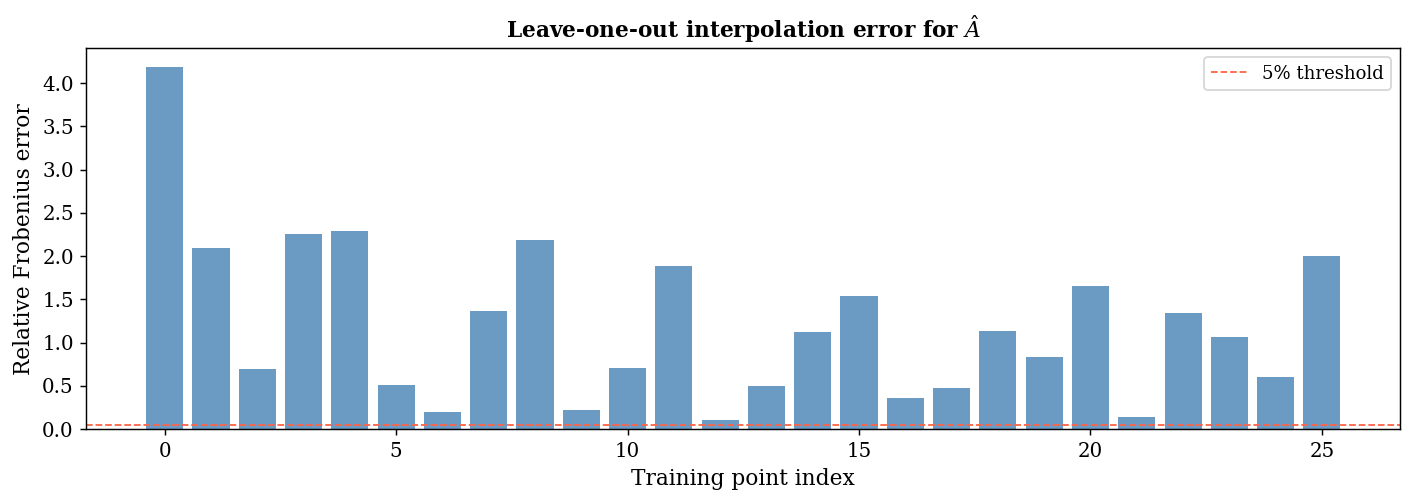

In [34]:
loo_A_errors = []

for held in range(M):
    train_mask   = np.arange(M) != held
    pts_train    = pts[train_mask]
    A_train      = A_arr[train_mask]
    A_held       = A_arr[held]
    pt_query     = pts[[held]]

    A_flat_train = A_train.reshape(M - 1, n * n)
    A_pred_flat  = np.zeros(n * n)

    for col in range(n * n):
        rbf = RBFInterpolator(pts_train, A_flat_train[:, col],
                              kernel='thin_plate_spline', smoothing=0.5)
        A_pred_flat[col] = rbf(pt_query)[0]

    A_pred = A_pred_flat.reshape(n, n)
    err    = (np.linalg.norm(A_pred - A_held, 'fro') /
              np.linalg.norm(A_held, 'fro'))
    loo_A_errors.append(err)

loo_errors = np.array(loo_A_errors)
print(f'Leave-one-out interpolation error for A_hat:')
print(f'  Mean  : {loo_errors.mean():.2e}')
print(f'  Max   : {loo_errors.max():.2e}')
worst_idx = np.argmax(loo_errors)
print(f'  Worst : log10k={pts[worst_idx,0]:.2f}  S={pts[worst_idx,1]:.0f}')

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(M), loo_errors, color='steelblue', alpha=0.8)
ax.axhline(0.05, color='tomato', ls='--', lw=1, label='5% threshold')
ax.set_xlabel('Training point index')
ax.set_ylabel('Relative Frobenius error')
ax.set_title('Leave-one-out interpolation error for $\\hat{A}$')
ax.legend()
plt.tight_layout(); plt.show()

## 4. Interpolation surface visualisation

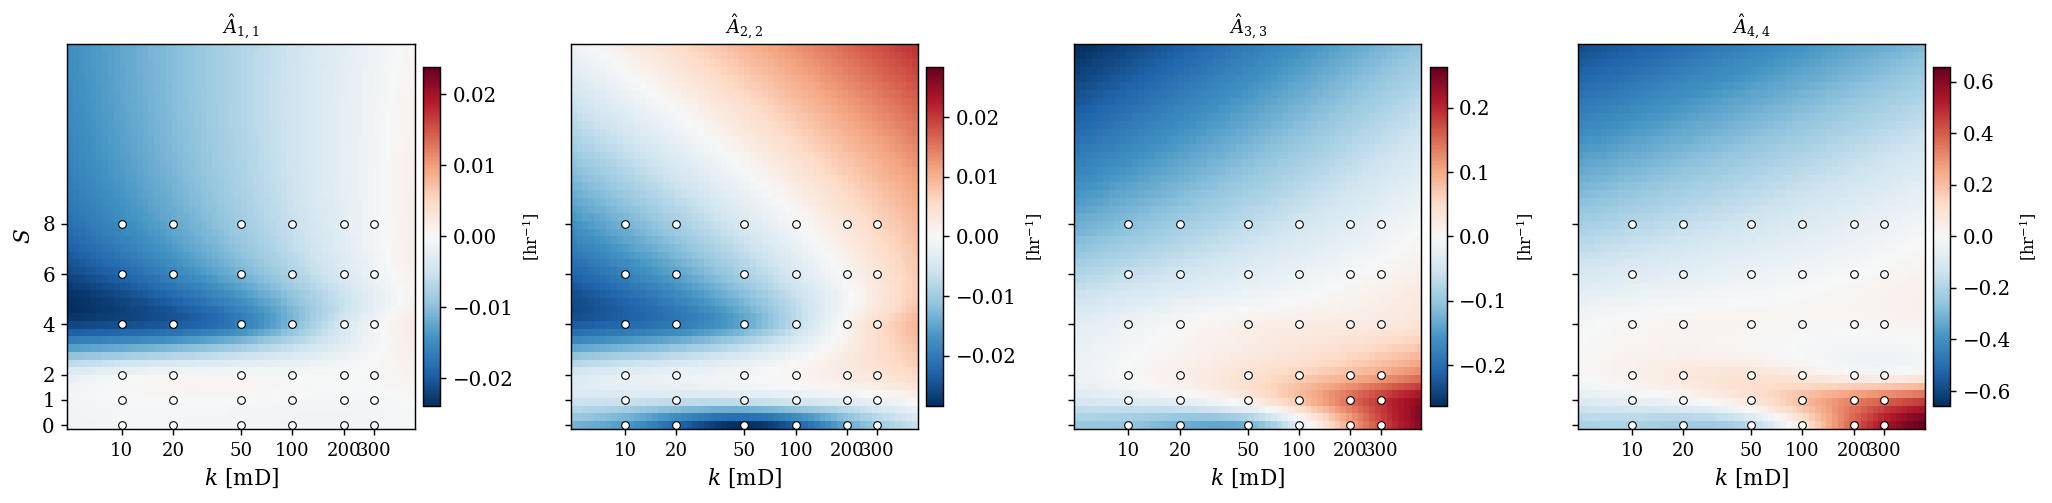

In [35]:
def eval_operator(interps, shape, k_query, s_query):
    pt   = np.array([[np.log10(k_query), s_query]])
    vals = np.array([f(pt)[0] for f in interps])
    return vals.reshape(shape)

k_fine = np.logspace(np.log10(5), np.log10(500), 60)
s_fine = np.linspace(0, 15, 50)
KK, SS = np.meshgrid(k_fine, s_fine)

n_report  = 4
diag_maps = np.zeros((n_report, *KK.shape))

for gi in range(KK.shape[0]):
    for gj in range(KK.shape[1]):
        A_q = eval_operator(A_interps, A_shape, KK[gi, gj], SS[gi, gj])
        for m in range(n_report):
            diag_maps[m, gi, gj] = A_q[m, m]

x_ticks      = np.log10(K_GRID)
x_ticklabels = [str(k) for k in K_GRID]
y_ticks      = S_GRID

fig, axes = plt.subplots(1, n_report, figsize=(4 * n_report, 4))
for m in range(n_report):
    ax  = axes[m]
    dat = diag_maps[m]
    lim = np.abs(dat).max()
    im  = ax.pcolormesh(np.log10(KK), SS, dat,
                        cmap='RdBu_r', shading='auto', vmin=-lim, vmax=lim)
    ax.scatter(np.log10(np.tile(K_GRID, len(S_GRID))),
               np.repeat(S_GRID, len(K_GRID)),
               c='white', s=18, edgecolors='k', linewidths=0.6, zorder=5)
    ax.set_xticks(x_ticks); ax.set_xticklabels(x_ticklabels, fontsize=10)
    ax.set_xlabel('$k$ [mD]')
    ax.set_yticks(y_ticks)
    if m == 0:
        ax.set_yticklabels(y_ticks); ax.set_ylabel('$S$')
    else:
        ax.set_yticklabels([])
    ax.set_title(f'$\\hat{{A}}_{{{m+1},{m+1}}}$', fontsize=10, pad=5)
    cb = plt.colorbar(im, ax=ax, shrink=0.88, pad=0.02)
    cb.set_label(r'$[\mathrm{hr}^{-1}]$', fontsize=9)

plt.tight_layout(w_pad=0.6)
plt.savefig('fig_A_diagonal.pdf', dpi=150, bbox_inches='tight')
plt.show()

## 5. Save interpolants

In [36]:
with open(INTERP_DIR / 'A_hat_interp.pkl', 'wb') as f:
    pickle.dump({'interps': A_interps, 'shape': A_shape}, f)

with open(INTERP_DIR / 'B_hat_interp.pkl', 'wb') as f:
    pickle.dump({'interps': B_interps, 'shape': B_shape}, f)

with open(INTERP_DIR / 'C_hat_interp.pkl', 'wb') as f:
    pickle.dump({'interps': C_interps, 'shape': C_shape}, f)

meta = {
    'k_grid'         : K_GRID,
    'S_grid'         : S_GRID,
    'n_modes'        : int(n),
    'n_training_pts' : int(M),
    'n_excluded'     : len(excluded),
    'excluded_cases' : [e[0] for e in excluded],
    'kernel'         : 'thin_plate_spline',
    'smoothing'      : 0.5,
    'interp_coords'  : 'log10(k), S',
    'loo_mean_error' : float(loo_errors.mean()),
    'loo_max_error'  : float(loo_errors.max()),
}
with open(INTERP_DIR / 'interp_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved:')
for p in sorted(INTERP_DIR.iterdir()):
    print(f'  {p.name:<30}  {p.stat().st_size/1e3:.1f} kB')
print(f'\nReady for NB04 — Validation')

Saved:
  A_hat_interp.pkl                96.7 kB
  B_hat_interp.pkl                10.4 kB
  C_hat_interp.pkl                10.4 kB
  interp_metadata.json            0.6 kB

Ready for NB04 — Validation
